We will take the csv "TTC_Subway_Delay_Data_since_2025.csv" and we will use it to create a Python script that will label the subway stations as being on Line 1, 2, or 4. If a subway station intersects two lines, count it for both lines. We will use this information to make a bar graph in Python to show number of average delays per station for each subway line (for all delays over zero). Then we will also use python to make a new csv, that will have the total delays each month across all stations. We will save that updated csv file as "ttc_delays_per_month_for_excel.csv", and then use it to make a line graph in Excel, showing number of delays across months.

Current working directory: c:\Users\vigna\Documents\DSI\visualization\02_activities\assignments
Looking for: TTC_Subway_Delay_Data_since_2025.csv
Months range: 2025-01 to 2025-12

Delays per line (2025) - normalized by stations:
Assigned Line  Total Delays  Stations  Avg Delays per Station
           BD          3808        31              122.838710
           YU          4208        38              110.736842
          SHP           344         5               68.800000

Bar chart saved as: viz_avg_delays_per_station_2025.png


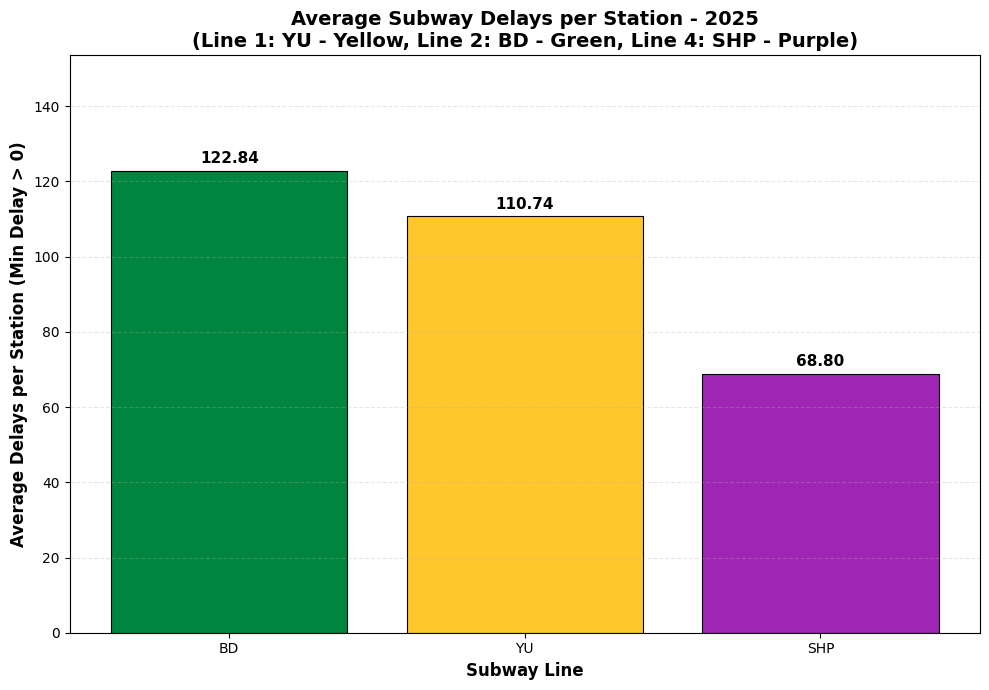


Total delays per month (2025) - for Excel line graph:
  Month  Total Delays
2025-01           780
2025-02           886
2025-03           712
2025-04           683
2025-05           668
2025-06           612
2025-07           624
2025-08           688
2025-09           570
2025-10           655
2025-11           742
2025-12           740

Monthly data saved as: ttc_delays_per_month_for_excel.csv
Open this in Excel → select Month & Total Delays → Insert → Line Chart


In [ ]:
# Assignment 3 – Python Visualizations

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ────────────────────────────────────────────────
# CONFIG – files in same folder as notebook/script
# ────────────────────────────────────────────────
csv_filename = "TTC_Subway_Delay_Data_since_2025.csv"
bar_png = "viz_avg_delays_per_station_2025.png"
excel_line_csv = "ttc_delays_per_month_for_excel.csv"  # small CSV for Excel line graph

# Verify CSV exists
print("Current working directory:", os.getcwd())
print("Looking for:", csv_filename)
if not os.path.exists(csv_filename):
    print("\nERROR: CSV not found.")
    print("Files in folder:", os.listdir('.'))
    raise FileNotFoundError(f"Cannot find {csv_filename}")

# ────────────────────────────────────────────────
# 1. Load data
# ────────────────────────────────────────────────
df = pd.read_csv(csv_filename)

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date', 'Line', 'Station', 'Min Delay'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.to_period('M').astype(str)

print(f"Months range: {df['Month'].min()} to {df['Month'].max()}")

# ────────────────────────────────────────────────
# 2. Station → Lines mapping (YU, BD, SHP only)
# ────────────────────────────────────────────────
station_to_lines = {
    'FINCH STATION': ['YU'],
    'YORK MILLS STATION': ['YU'],
    'NORTH YORK CTR STATION': ['YU'],
    'SHEPPARD WEST STATION': ['YU'],
    'WILSON STATION': ['YU'],
    'YORKDALE STATION': ['YU'],
    'LAWRENCE STATION': ['YU'],
    'EGLINTON STATION': ['YU'],
    'ST CLAIR STATION': ['YU'],
    'ST CLAIR WEST STATION': ['YU'],
    'DUPONT STATION': ['YU'],
    'SPADINA YUS STATION': ['YU'],
    'ST GEORGE YUS STATION': ['YU', 'BD'],
    'MUSEUM STATION': ['YU'],
    'QUEEN\'S PARK STATION': ['YU'],
    'ST PATRICK STATION': ['YU'],
    'OSGOODE STATION': ['YU'],
    'ST ANDREW STATION': ['YU'],
    'UNION STATION': ['YU'],
    'KING STATION': ['YU'],
    'QUEEN STATION': ['YU'],
    'DUNDAS STATION': ['YU'],
    'COLLEGE STATION': ['YU'],
    'WELLESLEY STATION': ['YU'],
    'BLOOR STATION': ['YU', 'BD'],
    'VAUGHAN MC STATION': ['YU'],
    'HIGHWAY 407 STATION': ['YU'],
    'PIONEER VILLAGE STATION': ['YU'],
    'FINCH WEST STATION': ['YU'],

    'KENNEDY BD STATION': ['BD'],
    'WARDEN STATION': ['BD'],
    'VICTORIA PARK STATION': ['BD'],
    'WOODBINE STATION': ['BD'],
    'MAIN STREET STATION': ['BD'],
    'COXWELL STATION': ['BD'],
    'GREENWOOD STATION': ['BD'],
    'DONLANDS STATION': ['BD'],
    'PAPE STATION': ['BD'],
    'BROADVIEW STATION': ['BD'],
    'CASTLE FRANK STATION': ['BD'],
    'SHERBOURNE STATION': ['BD'],
    'YONGE BD STATION': ['BD'],
    'BAY STATION': ['BD'],
    'ST GEORGE BD STATION': ['BD', 'YU'],
    'SPADINA BD STATION': ['BD', 'YU'],
    'CHRISTIE STATION': ['BD'],
    'BATHURST STATION': ['BD'],
    'DUFFERIN STATION': ['BD'],
    'LANSDOWNE STATION': ['BD'],
    'DUNDAS WEST STATION': ['BD'],
    'KEELE STATION': ['BD'],
    'ISLINGTON STATION': ['BD'],
    'ROYAL YORK STATION': ['BD'],
    'OLD MILL STATION': ['BD'],
    'JANE STATION': ['BD'],
    'RUNNYMEDE STATION': ['BD'],
    'KIPLING STATION': ['BD'],

    'SHEPPARD-YONGE STATION': ['SHP', 'YU'],
    'BAYVIEW STATION': ['SHP'],
    'BESSARION STATION': ['SHP'],
    'LESLIE STATION': ['SHP'],
    'DON MILLS STATION': ['SHP'],
}

df['Station'] = df['Station'].str.strip().str.upper()

# ────────────────────────────────────────────────
# 3. Explode multi-line stations
# ────────────────────────────────────────────────
delay_rows = []
for _, row in df.iterrows():
    station = row['Station']
    lines = station_to_lines.get(station, [])
    if lines:
        for line in lines:
            new_row = row.copy()
            new_row['Assigned Line'] = line
            delay_rows.append(new_row)

df_exploded = pd.DataFrame(delay_rows)

# ────────────────────────────────────────────────
# 4. Delays per line & avg per station
# ────────────────────────────────────────────────
df_delays = df_exploded[df_exploded['Min Delay'] > 0]

delays_by_line = (
    df_delays
    .groupby('Assigned Line')
    .size()
    .reset_index(name='Total Delays')
)

stations_per_line = {'YU': 38, 'BD': 31, 'SHP': 5}
delays_by_line['Stations'] = delays_by_line['Assigned Line'].map(stations_per_line)
delays_by_line['Avg Delays per Station'] = delays_by_line['Total Delays'] / delays_by_line['Stations']

delays_by_line = delays_by_line.sort_values('Avg Delays per Station', ascending=False)

print("\nDelays per line (2025) - normalized by stations:")
print(delays_by_line.to_string(index=False))

# ────────────────────────────────────────────────
# 5. Bar chart 
# ────────────────────────────────────────────────
plt.figure(figsize=(10, 7))

ttc_colors = {
    'YU': '#FFC72C',   # Yellow - Line 1
    'BD': '#00853E',   # Green - Line 2
    'SHP': '#9F26B5'   # Purple - Line 4
}

bar_colors = [ttc_colors.get(line, 'gray') for line in delays_by_line['Assigned Line']]

bars = plt.bar(
    delays_by_line['Assigned Line'],
    delays_by_line['Avg Delays per Station'],
    color=bar_colors,
    edgecolor='black',
    linewidth=0.8
)

# Bold title and axis labels
plt.title('Average Subway Delays per Station - 2025\n'
          '(Line 1: YU - Yellow, Line 2: BD - Green, Line 4: SHP - Purple)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Subway Line', fontsize=12, fontweight='bold')
plt.ylabel('Average Delays per Station (Min Delay > 0)', fontsize=12, fontweight='bold')

plt.grid(axis='y', alpha=0.3, linestyle='--')

# Labels with increased space
label_offset = 2  
for bar, v in zip(bars, delays_by_line['Avg Delays per Station']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + label_offset,
        f'{v:.2f}',
        ha='center',
        fontsize=11,
        fontweight='bold',
        color='black'
    )

plt.margins(y=0.25)  # extra top margin
plt.tight_layout()
plt.savefig(bar_png, dpi=300, bbox_inches='tight')
print(f"\nBar chart saved as: {bar_png}")

plt.show()

# ────────────────────────────────────────────────
# 6. Monthly delays summary for Excel line graph
# ────────────────────────────────────────────────
delays_per_month = (
    df_delays
    .groupby('Month')
    .size()
    .reset_index(name='Total Delays')
    .sort_values('Month')
)

print("\nTotal delays per month (2025) - for Excel line graph:")
print(delays_per_month.to_string(index=False))

# Save small CSV for Excel
delays_per_month.to_csv(excel_line_csv, index=False)
print(f"\nMonthly data saved as: {excel_line_csv}")
print("Open this in Excel → select Month & Total Delays → Insert → Line Chart")